## Pose Transforms

Those transforms can be applied to pose landmarks to transform them or perform data augmentation.

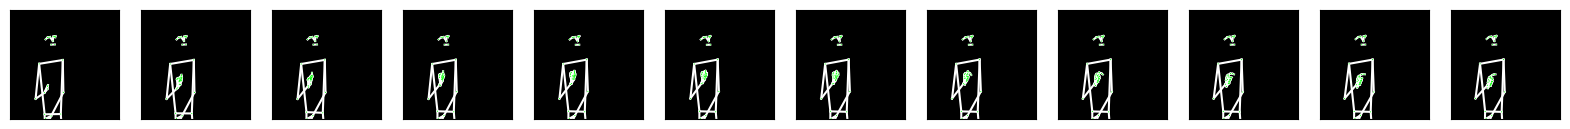

In [11]:
import numpy as np
from sign_language_tools.visualization.plot.landmarks import plot_landmarks_sequence
from sign_language_tools.pose.mediapipe.edges import FACE_EDGES, POSE_EDGES, HAND_EDGES
import os

FRAME = 5

landmarks = {}

landmarks["pose"] = np.load("../examples/ressources/pose.npy")
landmarks["right_hand"] = np.load("../examples/ressources/right_hand.npy")
landmarks["left_hand"] = np.load("../examples/ressources/left_hand.npy")


fig = plot_landmarks_sequence(landmarks, [POSE_EDGES, HAND_EDGES, HAND_EDGES])
fig.set_size_inches(20, 10)


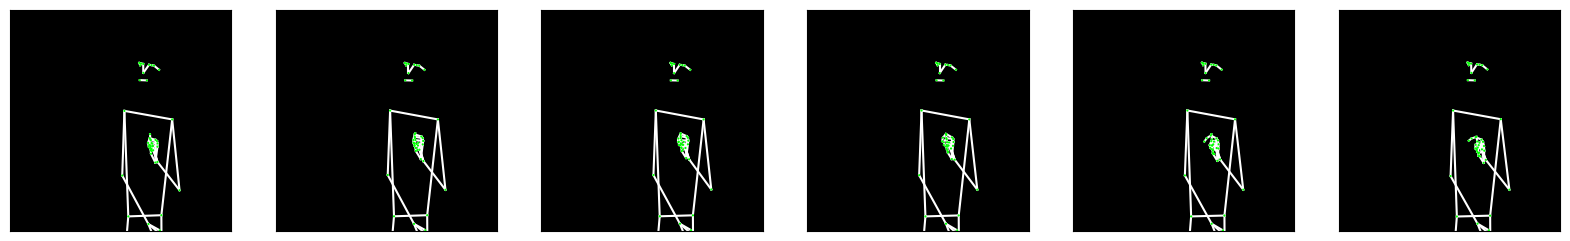

In [10]:
from sign_language_tools.pose.transform import *

# Creating transform pipeline
pipeline = [
    Concatenate(["pose", "right_hand", "left_hand"]),
    TemporalRandomCrop(6),
    HorizontalFlip(),
    Split({"pose":33, "right_hand": 21, "left_hand": 21})
]

x = landmarks
for transform in pipeline:
    x = transform(x)


fig = plot_landmarks_sequence(x, [POSE_EDGES, HAND_EDGES, HAND_EDGES])
fig.set_size_inches(20, 10)